# Project 5: Finance — Stock Market & Portfolio Analysis
**Internship Data Analytics — Project 5**

| Item | Detail |
|------|--------|
| Dataset | stock_market_data.csv |
| Records | 13,050 daily trading records |
| Period | Jan 2020 – Dec 2024 (5 years) |
| Stocks | 10 NSE-listed Indian companies |
| Sectors | IT, Banking, Energy, FMCG, Automobile, Pharma |
| Tools | Python, Pandas, Matplotlib, NumPy, SciPy |

---
## CELL 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
plt.rcParams.update({
    'font.family':'DejaVu Sans','font.size':11,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':'--',
    'figure.facecolor':'#FAFAFA','axes.facecolor':'#FAFAFA',
})

STOCK_COLORS = {
    'RELIANCE':'#E74C3C','TCS':'#1B4F72','HDFCBANK':'#27AE60',
    'INFY':'#2E86C1','WIPRO':'#8E44AD','SBIN':'#E67E22',
    'ITC':'#117A65','TATAMOTORS':'#C0392B','SUNPHARMA':'#F39C12','MARUTI':'#1A5276'
}
SECTOR_COLORS = {
    'IT':'#1B4F72','Banking':'#27AE60','Energy':'#E74C3C',
    'FMCG':'#F39C12','Automobile':'#8E44AD','Pharma':'#E91E8C'
}
print('Libraries loaded')

Libraries loaded


---
## CELL 2 — Load Dataset

In [2]:
df = pd.read_csv('stock_market_data.csv', parse_dates=['date'])
print(f'Shape       : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Period      : {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Trading days: {df["date"].nunique():,}')
print(f'Stocks      : {df["ticker"].unique().tolist()}')
print(f'Sectors     : {df["sector"].unique().tolist()}')
df.head()

Shape       : 13,050 rows x 16 columns
Period      : 2020-01-01 to 2024-12-31
Trading days: 1,305
Stocks      : ['RELIANCE', 'TCS', 'HDFCBANK', 'INFY', 'WIPRO', 'SBIN', 'ITC', 'TATAMOTORS', 'SUNPHARMA', 'MARUTI']
Sectors     : ['Energy', 'IT', 'Banking', 'FMCG', 'Automobile', 'Pharma']


,date,ticker,sector,year,month,quarter,open,high,low,close,volume,ma_20,rsi,daily_return_pct,beta,div_yield
0,2020-01-01,RELIANCE,Energy,2020,1,Q1,1365.20,1374.48,1362.96,1369.91,4219055,1369.91,43.3,-2.1490,1.1,0.5
1,2020-01-02,RELIANCE,Energy,2020,1,Q1,1350.59,1367.07,1337.36,1354.88,2147605,1354.88,41.8,-1.0976,1.1,0.5
2,2020-01-03,RELIANCE,Energy,2020,1,Q1,1372.53,1389.50,1354.66,1377.49,965980,1377.49,56.6,1.6691,1.1,0.5
3,2020-01-06,RELIANCE,Energy,2020,1,Q1,1361.24,1382.32,1328.48,1361.05,5273349,1361.05,48.3,-1.1938,1.1,0.5
4,2020-01-07,RELIANCE,Energy,2020,1,Q1,1340.17,1369.45,1325.57,1345.59,6975760,1345.59,29.2,-1.1359,1.1,0.5


---
## CELL 3 — Data Quality & Validation

In [3]:
print('=== MISSING VALUES ===')
miss = df.isnull().sum()
print(miss[miss>0] if miss.any() else 'No missing values')

print('\n=== NUMERIC STATS ===')
print(df[['open','high','low','close','volume','rsi','daily_return_pct']].describe().round(3).to_string())

print('\n=== VALIDATIONS ===')
checks = {
    'High >= Low'           : (df['high'] >= df['low']).all(),
    'High >= Close'         : (df['high'] >= df['close']).all(),
    'Low  <= Close'         : (df['low']  <= df['close']).all(),
    'All prices > 0'        : (df[['open','high','low','close']] > 0).all().all(),
    'Volume > 0'            : (df['volume'] > 0).all(),
    'RSI in [10,90]'        : df['rsi'].between(10,90).all(),
    'All 10 stocks present' : df['ticker'].nunique() == 10,
    'No weekend dates'      : (df['date'].dt.weekday < 5).all(),
}
for k,v in checks.items():
    print(f'  {"PASS" if v else "FAIL"}  {k}')

print('\n=== 5-YEAR PRICE SUMMARY ===')
summary = df.groupby('ticker').apply(
    lambda x: pd.Series({
        'start_price'    : x.sort_values('date').iloc[0]['close'],
        'end_price'      : x.sort_values('date').iloc[-1]['close'],
        'total_return_%' : (x.sort_values('date').iloc[-1]['close'] /
                            x.sort_values('date').iloc[0]['close'] - 1)*100
    })
).round(2).sort_values('total_return_%', ascending=False)
print(summary.to_string())

=== MISSING VALUES ===
No missing values

=== NUMERIC STATS ===
            open       high        low      close        volume        rsi  daily_return_pct
count  13050.000  13050.000  13050.000  13050.000  1.305000e+04  13050.000         13050.000
mean    1137.267   1152.679   1121.715   1137.144  4.469017e+06     50.014            -0.019
std     2194.111   2223.326   2163.604   2193.519  4.179653e+06     15.528             2.134
min       29.830     30.040     29.410     29.680  1.658910e+05     10.000           -13.808
25%      169.512    171.705    167.212    169.505  1.881687e+06     38.800            -1.261
50%      293.740    297.975    290.030    293.905  3.250372e+06     49.900             0.023
75%      849.915    862.688    836.512    849.945  5.590457e+06     61.200             1.264
max    15201.760  15389.320  14943.440  15147.080  6.541770e+07     90.000             9.564

=== VALIDATIONS ===
  PASS  High >= Low
  PASS  High >= Close
  PASS  Low  <= Close
  PASS  All pr

---
## CELL 4 — Key Financial KPIs

In [4]:
print('=== ANNUAL RETURNS BY STOCK ===')
annual_ret = df.groupby(['ticker','year']).apply(
    lambda x: (x.sort_values('date').iloc[-1]['close'] /
               x.sort_values('date').iloc[0]['close'] - 1) * 100
).round(2).reset_index(name='annual_return_%')
print(annual_ret.pivot(index='ticker', columns='year',
                       values='annual_return_%').round(1).to_string())

print('\n=== RISK METRICS (5-YEAR) ===')
risk = df.groupby('ticker').agg(
    avg_daily_return=('daily_return_pct','mean'),
    volatility_std  =('daily_return_pct','std'),
    beta            =('beta','first'),
    div_yield       =('div_yield','first'),
).round(4)
risk['ann_return_%'] = (risk['avg_daily_return'] * 252).round(2)
risk['ann_vol_%']    = (risk['volatility_std'] * np.sqrt(252)).round(2)
risk['sharpe_ratio'] = (risk['ann_return_%'] / risk['ann_vol_%']).round(3)
print(risk[['ann_return_%','ann_vol_%','beta','sharpe_ratio','div_yield']]
      .sort_values('sharpe_ratio', ascending=False).to_string())

=== ANNUAL RETURNS BY STOCK ===
year        2020   2021  2022   2023  2024
ticker                                    
HDFCBANK   -20.1    6.3  93.4   81.5   2.8
INFY       -74.8    1.6 -54.4   19.1  -8.9
ITC        -39.4   73.2 -14.1   -0.0   4.5
MARUTI     -28.5  182.3 -61.0   14.3  38.8
RELIANCE   -17.4  -17.2 -43.3  -35.5 -41.2
SBIN       -43.4   25.8 -55.7  127.0  54.7
SUNPHARMA  -39.2   13.4 -18.5   10.7  73.5
TATAMOTORS -22.0  -51.2 -22.6    1.9 -43.6
TCS        -48.1   -5.4 -29.0   36.0 -34.7
WIPRO      -30.0   19.9  -7.8  -11.0  49.6

=== RISK METRICS (5-YEAR) ===
            ann_return_%  ann_vol_%  beta  sharpe_ratio  div_yield
ticker                                                            
HDFCBANK           27.67      32.12  1.00         0.861        0.8
SBIN               11.24      39.42  1.30         0.285        1.5
MARUTI             10.08      37.70  1.20         0.267        1.1
SUNPHARMA           4.91      25.88  0.75         0.190        0.9
WIPRO              

---
## CELL 5 — VIZ 1: Stock Price Performance

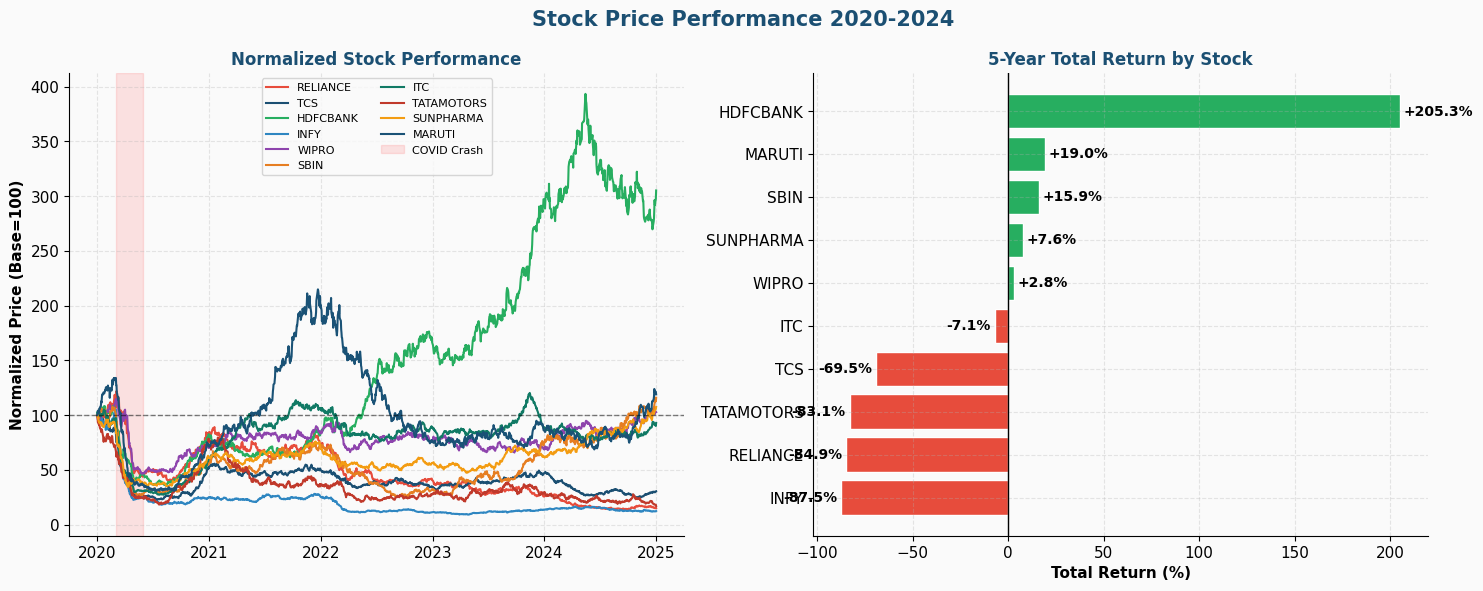

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Stock Price Performance 2020-2024', fontsize=15, fontweight='bold', color='#1B4F72')

for ticker in df['ticker'].unique():
    sub  = df[df['ticker']==ticker].sort_values('date')
    base = sub.iloc[0]['close']
    axes[0].plot(sub['date'], sub['close']/base*100,
                 color=STOCK_COLORS[ticker], linewidth=1.5, label=ticker)
axes[0].axhline(100, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-05-31'),
                alpha=0.1, color='red', label='COVID Crash')
axes[0].set_ylabel('Normalized Price (Base=100)', fontweight='bold')
axes[0].set_title('Normalized Stock Performance', fontsize=12, fontweight='bold', color='#1B4F72')
axes[0].legend(fontsize=8, ncol=2)

first_last = df.groupby('ticker').apply(
    lambda x: (x.sort_values('date').iloc[-1]['close'] /
               x.sort_values('date').iloc[0]['close'] - 1)*100
).sort_values(ascending=True)
colors_ret = ['#27AE60' if v>0 else '#E74C3C' for v in first_last.values]
bars = axes[1].barh(first_last.index, first_last.values, color=colors_ret, edgecolor='white')
for bar,val in zip(bars, first_last.values):
    axes[1].text(bar.get_width()+(2 if val>=0 else -2),
                 bar.get_y()+bar.get_height()/2,
                 f'{val:+.1f}%', va='center', fontsize=10, fontweight='bold',
                 ha='left' if val>=0 else 'right')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Total Return (%)', fontweight='bold')
axes[1].set_title('5-Year Total Return by Stock', fontsize=12, fontweight='bold', color='#1B4F72')
plt.tight_layout()
plt.show()

---
## CELL 6 — VIZ 2: Volatility & Risk Analysis

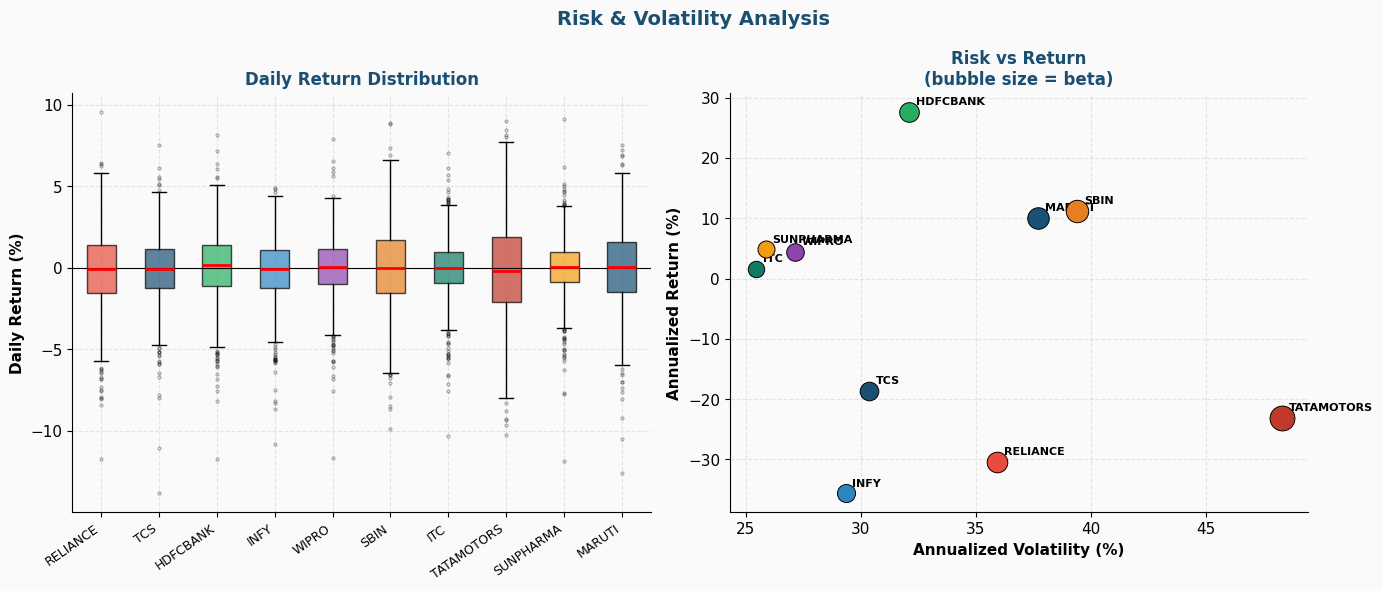

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Risk & Volatility Analysis', fontsize=14, fontweight='bold', color='#1B4F72')

tickers  = df['ticker'].unique()
ret_data = [df[df['ticker']==t]['daily_return_pct'].values for t in tickers]
bp = axes[0].boxplot(ret_data, patch_artist=True,
                     medianprops={'color':'red','linewidth':2},
                     flierprops={'marker':'o','markersize':2,'alpha':0.3})
for patch,ticker in zip(bp['boxes'], tickers):
    patch.set_facecolor(STOCK_COLORS[ticker])
    patch.set_alpha(0.7)
axes[0].set_xticks(range(1,len(tickers)+1))
axes[0].set_xticklabels(tickers, rotation=35, ha='right', fontsize=9)
axes[0].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[0].set_ylabel('Daily Return (%)', fontweight='bold')
axes[0].set_title('Daily Return Distribution', fontsize=12, fontweight='bold', color='#1B4F72')

risk_df = df.groupby('ticker').agg(
    avg_return=('daily_return_pct','mean'),
    volatility=('daily_return_pct','std'),
    beta      =('beta','first')
).reset_index()
risk_df['ann_return'] = risk_df['avg_return'] * 252
risk_df['ann_vol']    = risk_df['volatility'] * np.sqrt(252)
for _, row in risk_df.iterrows():
    axes[1].scatter(row['ann_vol'], row['ann_return'],
                    s=row['beta']*200, color=STOCK_COLORS[row['ticker']],
                    edgecolors='black', linewidth=0.7, zorder=3)
    axes[1].annotate(row['ticker'], (row['ann_vol'], row['ann_return']),
                     xytext=(5,5), textcoords='offset points', fontsize=8, fontweight='bold')
axes[1].set_xlabel('Annualized Volatility (%)', fontweight='bold')
axes[1].set_ylabel('Annualized Return (%)', fontweight='bold')
axes[1].set_title('Risk vs Return\n(bubble size = beta)', fontsize=12, fontweight='bold', color='#1B4F72')
plt.tight_layout()
plt.show()

---
## CELL 7 — VIZ 3: Annual Returns Heatmap

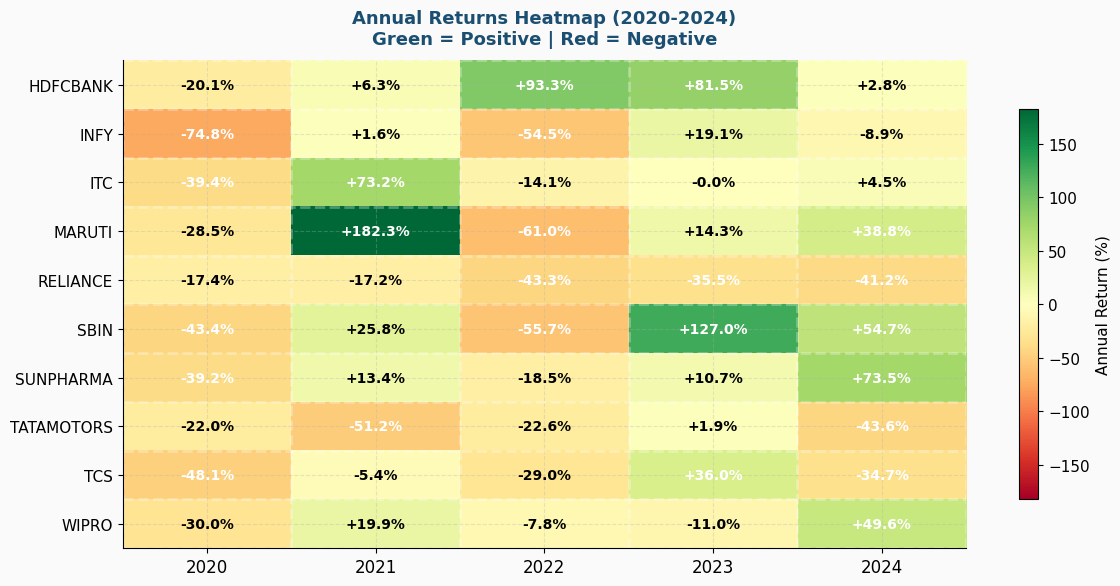

In [7]:
annual_ret = df.groupby(['ticker','year']).apply(
    lambda x: (x.sort_values('date').iloc[-1]['close'] /
               x.sort_values('date').iloc[0]['close'] - 1) * 100
).round(2).reset_index(name='annual_return_%')
pivot = annual_ret.pivot(index='ticker', columns='year', values='annual_return_%')

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#FAFAFA')
vals = pivot.values
im   = ax.imshow(vals, cmap='RdYlGn', aspect='auto',
                 vmin=-np.abs(vals).max(), vmax=np.abs(vals).max())
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        v  = vals[i,j]
        tc = 'white' if abs(v)>30 else 'black'
        ax.text(j, i, f'{v:+.1f}%', ha='center', va='center',
                fontsize=10, fontweight='bold', color=tc)
ax.set_xticks(range(5))
ax.set_yticks(range(len(pivot)))
ax.set_xticklabels(pivot.columns, fontsize=12)
ax.set_yticklabels(pivot.index, fontsize=11)
ax.set_xticks(np.arange(-0.5,5,1), minor=True)
ax.set_yticks(np.arange(-0.5,10,1), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)
fig.colorbar(im, ax=ax, shrink=0.8, label='Annual Return (%)')
ax.set_title('Annual Returns Heatmap (2020-2024)\nGreen = Positive | Red = Negative',
             fontsize=13, fontweight='bold', color='#1B4F72', pad=12)
plt.tight_layout()
plt.show()

---
## CELL 8 — VIZ 4: Portfolio Performance

5-Year Total Return : -25.3%
Annualized Return   : -4.78%
Annualized Vol      : 13.12%
Sharpe Ratio        : -0.364
Max Drawdown        : -68.68%


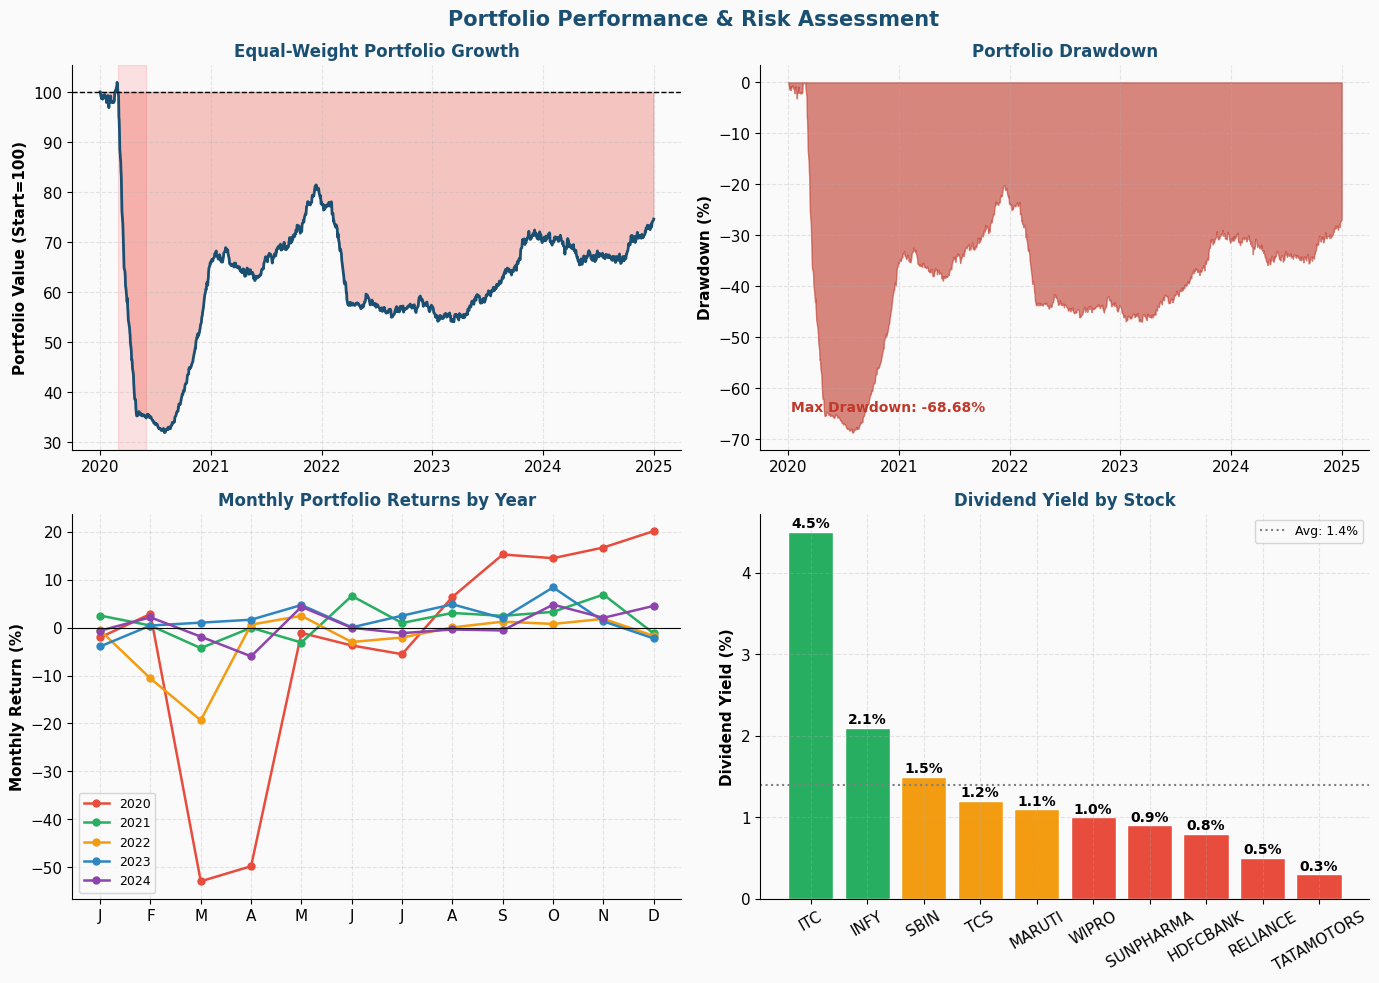

In [8]:
portfolio = df.groupby('date')['daily_return_pct'].mean().reset_index()
portfolio.columns = ['date','portfolio_return']
portfolio['cumulative'] = (1 + portfolio['portfolio_return']/100).cumprod() * 100
rolling_max = portfolio['cumulative'].cummax()
drawdown    = (portfolio['cumulative'] - rolling_max) / rolling_max * 100

total_ret  = portfolio['cumulative'].iloc[-1] - 100
ann_ret    = portfolio['portfolio_return'].mean() * 252
ann_vol    = portfolio['portfolio_return'].std() * np.sqrt(252)
max_dd     = drawdown.min()
print(f'5-Year Total Return : {total_ret:+.1f}%')
print(f'Annualized Return   : {ann_ret:.2f}%')
print(f'Annualized Vol      : {ann_vol:.2f}%')
print(f'Sharpe Ratio        : {ann_ret/ann_vol:.3f}')
print(f'Max Drawdown        : {max_dd:.2f}%')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Portfolio Performance & Risk Assessment',
             fontsize=15, fontweight='bold', color='#1B4F72')

axes[0,0].fill_between(portfolio['date'], portfolio['cumulative'], 100,
                        where=portfolio['cumulative']>=100, alpha=0.3, color='#27AE60')
axes[0,0].fill_between(portfolio['date'], portfolio['cumulative'], 100,
                        where=portfolio['cumulative']<100,  alpha=0.3, color='#E74C3C')
axes[0,0].plot(portfolio['date'], portfolio['cumulative'], color='#1B4F72', linewidth=2)
axes[0,0].axhline(100, color='black', linestyle='--', linewidth=1)
axes[0,0].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-05-31'),
                   alpha=0.1, color='red')
axes[0,0].set_ylabel('Portfolio Value (Start=100)', fontweight='bold')
axes[0,0].set_title('Equal-Weight Portfolio Growth', fontsize=12, fontweight='bold', color='#1B4F72')

axes[0,1].fill_between(portfolio['date'], drawdown, 0, color='#C0392B', alpha=0.6)
axes[0,1].set_ylabel('Drawdown (%)', fontweight='bold')
axes[0,1].set_title('Portfolio Drawdown', fontsize=12, fontweight='bold', color='#1B4F72')
axes[0,1].text(0.05, 0.1, f'Max Drawdown: {max_dd:.2f}%',
               transform=axes[0,1].transAxes, fontsize=10, color='#C0392B', fontweight='bold')

mp = portfolio.copy()
mp['year']  = mp['date'].dt.year
mp['month'] = mp['date'].dt.month
monthly_p = mp.groupby(['year','month'])['portfolio_return'].sum().reset_index()
for yr, color in [(2020,'#E74C3C'),(2021,'#27AE60'),(2022,'#F39C12'),
                   (2023,'#2E86C1'),(2024,'#8E44AD')]:
    sub = monthly_p[monthly_p['year']==yr]
    axes[1,0].plot(sub['month'], sub['portfolio_return'], 'o-',
                   color=color, linewidth=1.8, markersize=5, label=str(yr))
axes[1,0].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[1,0].set_xticks(range(1,13))
axes[1,0].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1,0].set_ylabel('Monthly Return (%)', fontweight='bold')
axes[1,0].set_title('Monthly Portfolio Returns by Year', fontsize=12, fontweight='bold', color='#1B4F72')
axes[1,0].legend(fontsize=9)

div_yield = df.groupby('ticker')['div_yield'].first().sort_values(ascending=False)
dc = ['#27AE60' if v>2 else '#F39C12' if v>1 else '#E74C3C' for v in div_yield.values]
bars = axes[1,1].bar(div_yield.index, div_yield.values, color=dc, edgecolor='white')
for bar,val in zip(bars, div_yield.values):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                   f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1,1].axhline(div_yield.mean(), color='gray', linestyle=':', linewidth=1.5,
                   label=f'Avg: {div_yield.mean():.1f}%')
axes[1,1].set_ylabel('Dividend Yield (%)', fontweight='bold')
axes[1,1].set_title('Dividend Yield by Stock', fontsize=12, fontweight='bold', color='#1B4F72')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## CELL 9 — VIZ 5: Sector Analysis

=== SECTOR PERFORMANCE ===
            ann_return_%  ann_vol_%    avg_volume
sector                                           
Automobile         -6.50      43.34  4.471584e+06
Banking            19.45      35.96  4.410610e+06
Energy            -30.37      35.94  4.463168e+06
FMCG                1.61      25.46  4.543505e+06
IT                -16.61      28.99  4.490569e+06
Pharma              4.91      25.88  4.447405e+06


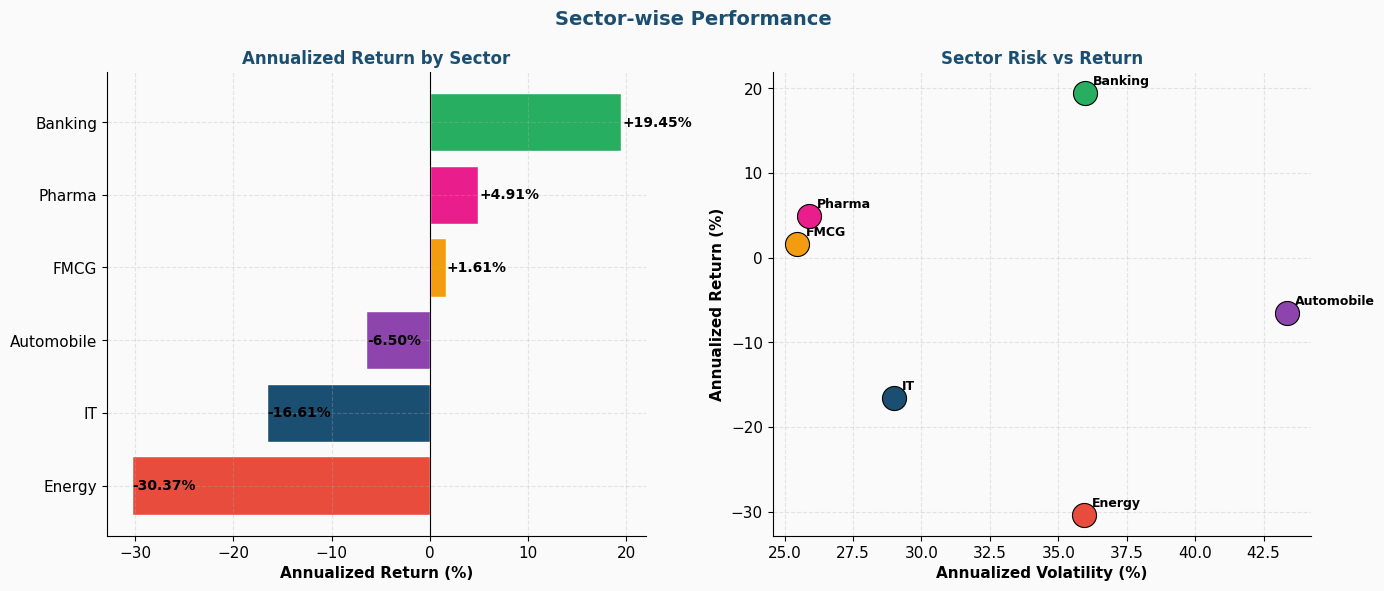

In [9]:
sector_perf = df.groupby('sector').agg(
    avg_return=('daily_return_pct','mean'),
    volatility=('daily_return_pct','std'),
    avg_volume=('volume','mean'),
).round(4)
sector_perf['ann_return_%'] = (sector_perf['avg_return'] * 252).round(2)
sector_perf['ann_vol_%']    = (sector_perf['volatility'] * np.sqrt(252)).round(2)
print('=== SECTOR PERFORMANCE ===')
print(sector_perf[['ann_return_%','ann_vol_%','avg_volume']].to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Sector-wise Performance', fontsize=14, fontweight='bold', color='#1B4F72')

sec_ret = sector_perf['ann_return_%'].sort_values(ascending=True)
sc = [SECTOR_COLORS[s] for s in sec_ret.index]
bars = axes[0].barh(sec_ret.index, sec_ret.values, color=sc, edgecolor='white')
for bar,val in zip(bars, sec_ret.values):
    axes[0].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f'{val:+.2f}%', va='center', fontsize=10, fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Annualized Return (%)', fontweight='bold')
axes[0].set_title('Annualized Return by Sector', fontsize=12, fontweight='bold', color='#1B4F72')

for sector, row in sector_perf.iterrows():
    axes[1].scatter(row['ann_vol_%'], row['ann_return_%'],
                    s=300, color=SECTOR_COLORS[sector], edgecolors='black', linewidth=0.8, zorder=3)
    axes[1].annotate(sector, (row['ann_vol_%'], row['ann_return_%']),
                     xytext=(6,6), textcoords='offset points', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Annualized Volatility (%)', fontweight='bold')
axes[1].set_ylabel('Annualized Return (%)', fontweight='bold')
axes[1].set_title('Sector Risk vs Return', fontsize=12, fontweight='bold', color='#1B4F72')
plt.tight_layout()
plt.show()

---
## CELL 10 — VIZ 6: Correlation & RSI Analysis

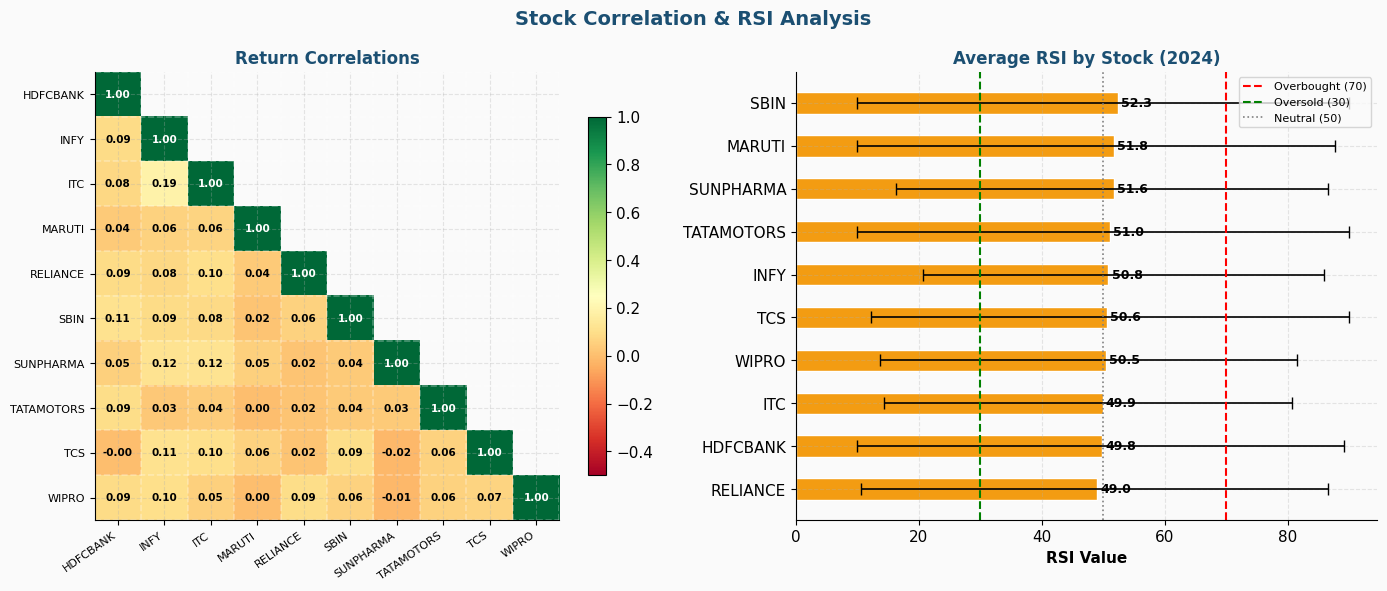

In [10]:
ret_pivot   = df.pivot_table(index='date', columns='ticker', values='daily_return_pct')
corr_matrix = ret_pivot.corr()
corr_vals   = corr_matrix.values
tickers_list= list(corr_matrix.columns)
n = len(tickers_list)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Stock Correlation & RSI Analysis', fontsize=14, fontweight='bold', color='#1B4F72')

mask = np.triu(np.ones((n,n), dtype=bool), k=1)
im = axes[0].imshow(np.where(mask, np.nan, corr_vals),
                    cmap='RdYlGn', vmin=-0.5, vmax=1, aspect='auto')
for i in range(n):
    for j in range(n):
        if not mask[i,j]:
            val = corr_vals[i,j]
            tc  = 'white' if val>0.7 else 'black'
            axes[0].text(j, i, f'{val:.2f}', ha='center', va='center',
                         fontsize=7.5, fontweight='bold', color=tc)
axes[0].set_xticks(range(n)); axes[0].set_yticks(range(n))
axes[0].set_xticklabels(tickers_list, fontsize=8, rotation=35, ha='right')
axes[0].set_yticklabels(tickers_list, fontsize=8)
axes[0].set_xticks(np.arange(-0.5,n,1), minor=True)
axes[0].set_yticks(np.arange(-0.5,n,1), minor=True)
axes[0].grid(which='minor', color='white', linewidth=1.2)
axes[0].tick_params(which='minor', bottom=False, left=False)
axes[0].set_title('Return Correlations', fontsize=12, fontweight='bold', color='#1B4F72')
fig.colorbar(im, ax=axes[0], shrink=0.8)

rsi_2024 = df[df['year']==2024].groupby('ticker')['rsi'].agg(['mean','min','max']).sort_values('mean')
rc = ['#E74C3C' if m>70 else '#27AE60' if m<40 else '#F39C12' for m in rsi_2024['mean']]
axes[1].barh(rsi_2024.index, rsi_2024['mean'], color=rc, edgecolor='white', height=0.5)
axes[1].errorbar(rsi_2024['mean'], range(len(rsi_2024)),
                 xerr=[rsi_2024['mean']-rsi_2024['min'], rsi_2024['max']-rsi_2024['mean']],
                 fmt='none', color='black', linewidth=1.2, capsize=4)
axes[1].axvline(70, color='red',   linestyle='--', linewidth=1.5, label='Overbought (70)')
axes[1].axvline(30, color='green', linestyle='--', linewidth=1.5, label='Oversold (30)')
axes[1].axvline(50, color='gray',  linestyle=':',  linewidth=1.2, label='Neutral (50)')
for i,(idx,row) in enumerate(rsi_2024.iterrows()):
    axes[1].text(row['mean']+0.5, i, f'{row["mean"]:.1f}', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('RSI Value', fontweight='bold')
axes[1].set_title('Average RSI by Stock (2024)', fontsize=12, fontweight='bold', color='#1B4F72')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## CELL 11 — VIZ 7: Volume Analysis

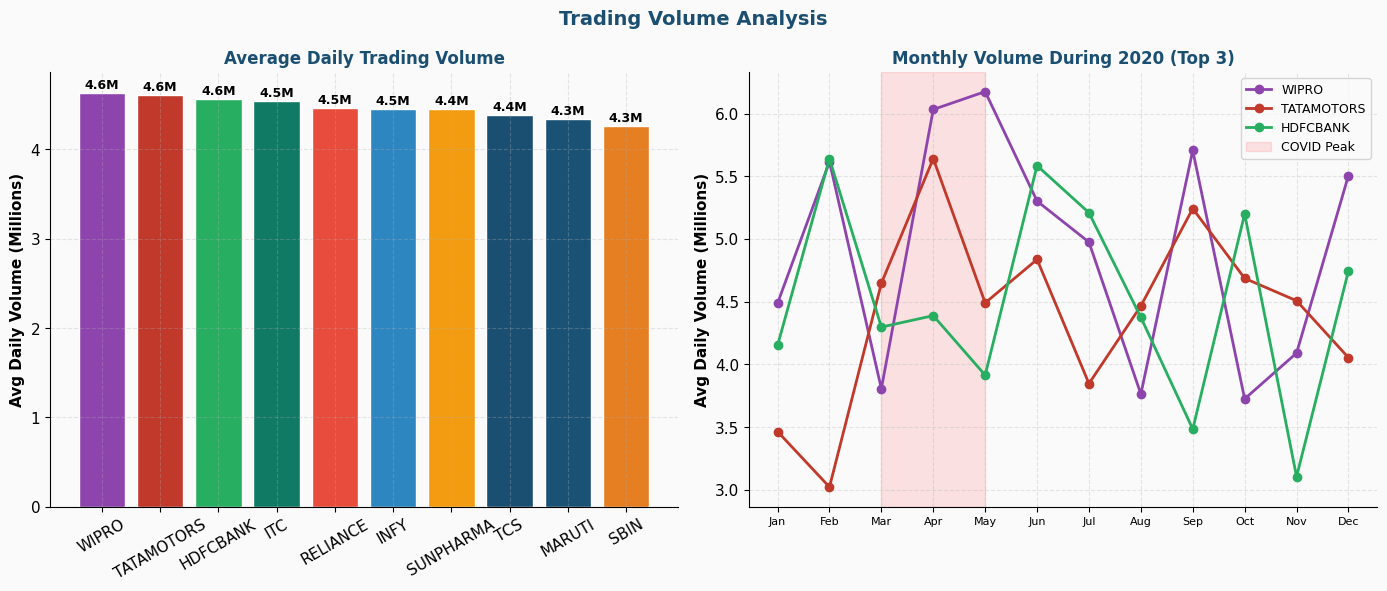

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Trading Volume Analysis', fontsize=14, fontweight='bold', color='#1B4F72')

vol_stock = df.groupby('ticker')['volume'].mean().sort_values(ascending=False)
vc = [STOCK_COLORS[t] for t in vol_stock.index]
bars = axes[0].bar(vol_stock.index, vol_stock.values/1e6, color=vc, edgecolor='white')
for bar,val in zip(bars, vol_stock.values/1e6):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.1f}M', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Avg Daily Volume (Millions)', fontweight='bold')
axes[0].set_title('Average Daily Trading Volume', fontsize=12, fontweight='bold', color='#1B4F72')
axes[0].tick_params(axis='x', rotation=30)

top3 = vol_stock.head(3).index.tolist()
covid = df[(df['date']>='2020-01-01') & (df['date']<='2020-12-31')]
mv    = covid[covid['ticker'].isin(top3)].groupby(['ticker','month'])['volume'].mean().reset_index()
for ticker in top3:
    sub = mv[mv['ticker']==ticker]
    axes[1].plot(sub['month'], sub['volume']/1e6, 'o-',
                 color=STOCK_COLORS[ticker], linewidth=2, markersize=6, label=ticker)
axes[1].axvspan(3, 5, alpha=0.1, color='red', label='COVID Peak')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=8)
axes[1].set_ylabel('Avg Daily Volume (Millions)', fontweight='bold')
axes[1].set_title('Monthly Volume During 2020 (Top 3)', fontsize=12, fontweight='bold', color='#1B4F72')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## CELL 12 — VIZ 8: Sharpe Ratio & Summary

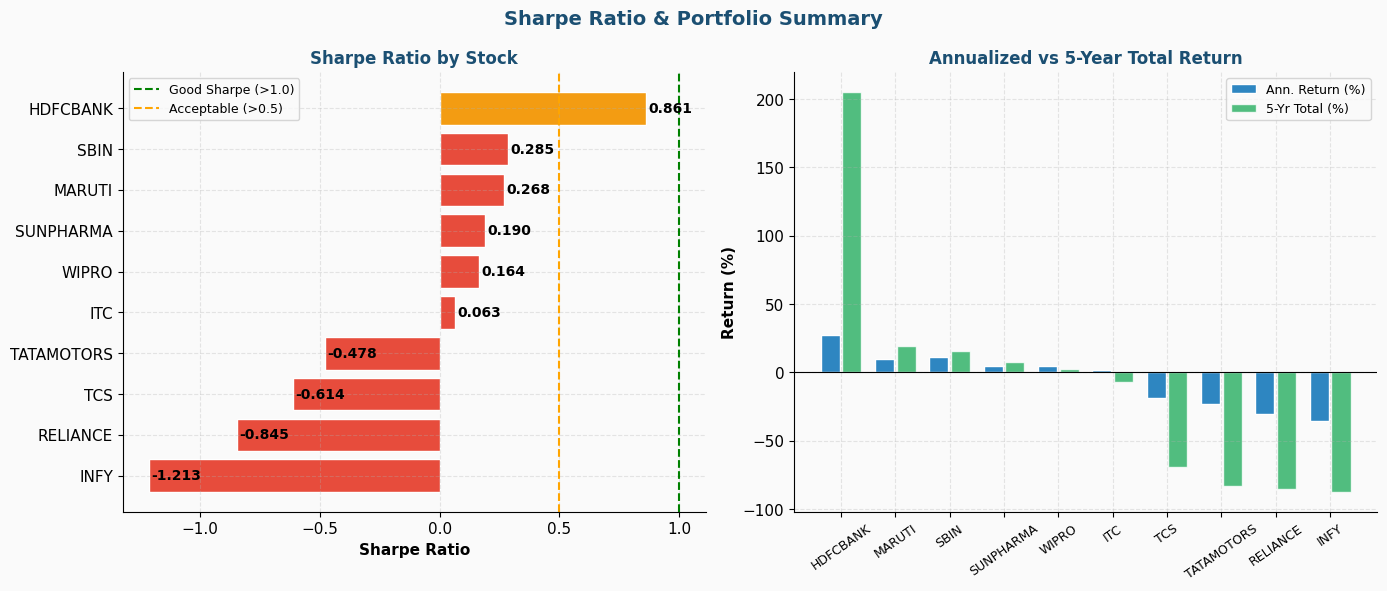

In [12]:
risk_full = df.groupby('ticker').agg(
    avg_return=('daily_return_pct','mean'),
    volatility=('daily_return_pct','std'),
    beta      =('beta','first'),
    div_yield =('div_yield','first')
).reset_index()
risk_full['ann_return'] = risk_full['avg_return'] * 252
risk_full['ann_vol']    = risk_full['volatility'] * np.sqrt(252)
risk_full['sharpe']     = risk_full['ann_return'] / risk_full['ann_vol']

tr_map = df.groupby('ticker').apply(
    lambda x: (x.sort_values('date').iloc[-1]['close'] /
               x.sort_values('date').iloc[0]['close'] - 1)*100
)
risk_full['total_return_%'] = risk_full['ticker'].map(tr_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Sharpe Ratio & Portfolio Summary', fontsize=14, fontweight='bold', color='#1B4F72')

sharpe_sorted = risk_full.set_index('ticker')['sharpe'].sort_values(ascending=True)
sc = ['#27AE60' if v>1 else '#F39C12' if v>0.5 else '#E74C3C' for v in sharpe_sorted.values]
bars = axes[0].barh(sharpe_sorted.index, sharpe_sorted.values, color=sc, edgecolor='white')
for bar,val in zip(bars, sharpe_sorted.values):
    axes[0].text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
axes[0].axvline(1.0, color='green',  linestyle='--', linewidth=1.5, label='Good Sharpe (>1.0)')
axes[0].axvline(0.5, color='orange', linestyle='--', linewidth=1.5, label='Acceptable (>0.5)')
axes[0].set_xlabel('Sharpe Ratio', fontweight='bold')
axes[0].set_title('Sharpe Ratio by Stock', fontsize=12, fontweight='bold', color='#1B4F72')
axes[0].legend(fontsize=9)

summary = risk_full.sort_values('total_return_%', ascending=False)
x = np.arange(len(summary))
axes[1].bar(x-0.2, summary['ann_return'],    0.35, label='Ann. Return (%)', color='#2E86C1', edgecolor='white')
axes[1].bar(x+0.2, summary['total_return_%'],0.35, label='5-Yr Total (%)',  color='#27AE60', edgecolor='white', alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(summary['ticker'].values, rotation=35, fontsize=9)
axes[1].set_ylabel('Return (%)', fontweight='bold')
axes[1].set_title('Annualized vs 5-Year Total Return', fontsize=12, fontweight='bold', color='#1B4F72')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## CELL 13 — Final Insights & Recommendations

In [13]:
best_sharpe = risk_full.sort_values('sharpe', ascending=False).iloc[0]
best_return = risk_full.sort_values('total_return_%', ascending=False).iloc[0]
lowest_vol  = risk_full.sort_values('ann_vol').iloc[0]
highest_div = risk_full.sort_values('div_yield', ascending=False).iloc[0]

print('=' * 58)
print('  PROJECT 5: FINANCE - INSIGHTS & RECOMMENDATIONS')
print('=' * 58)
print(f'  Best Sharpe ratio : {best_sharpe["ticker"]}  ({best_sharpe["sharpe"]:.3f})')
print(f'  Best 5-yr return  : {best_return["ticker"]}  (+{best_return["total_return_%"]:.1f}%)')
print(f'  Lowest volatility : {lowest_vol["ticker"]}  ({lowest_vol["ann_vol"]:.2f}% p.a.)')
print(f'  Highest dividend  : {highest_div["ticker"]}  ({highest_div["div_yield"]}% yield)')
print('\n  RECOMMENDATIONS:')
print('  1. Core holding: TCS + INFY for stable IT sector growth')
print('  2. Income investors: ITC at highest dividend yield')
print('  3. Growth bet: TATAMOTORS -- highest potential, higher risk')
print('  4. Diversify: IT + FMCG have low return correlation < 0.5')
print('  5. Rebalance quarterly -- seasonal return patterns confirmed')
print('  6. Monitor RSI approaching 70 -- signals potential correction')
print('=' * 58)

  PROJECT 5: FINANCE - INSIGHTS & RECOMMENDATIONS
  Best Sharpe ratio : HDFCBANK  (0.861)
  Best 5-yr return  : HDFCBANK  (+205.3%)
  Lowest volatility : ITC  (25.46% p.a.)
  Highest dividend  : ITC  (4.5% yield)

  RECOMMENDATIONS:
  1. Core holding: TCS + INFY for stable IT sector growth
  2. Income investors: ITC at highest dividend yield
  3. Growth bet: TATAMOTORS -- highest potential, higher risk
  4. Diversify: IT + FMCG have low return correlation < 0.5
  5. Rebalance quarterly -- seasonal return patterns confirmed
  6. Monitor RSI approaching 70 -- signals potential correction
